In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,auc,fpr

data = pd.read_csv("accident.csv")
data.head()

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
0,56,Female,27.0,No,No,1
1,69,Female,46.0,No,Yes,1
2,46,Male,46.0,Yes,Yes,0
3,32,Male,117.0,No,Yes,0
4,60,Female,40.0,Yes,Yes,0


In [35]:
data.tail(2)

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
198,20,Male,103.0,No,Yes,1
199,56,Female,43.0,No,Yes,1


In [36]:
print("Missing value:\n",data.isnull().sum())

Missing value:
 Age                0
Gender             1
Speed_of_Impact    3
Helmet_Used        0
Seatbelt_Used      0
Survived           0
dtype: int64


In [37]:
data.loc[:,'Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data.loc[:,'Speed_of_Impact'] = data['Speed_of_Impact'].fillna(data['Speed_of_Impact'].median())
print("Missing value:\n",data.isnull().sum())

Missing value:
 Age                0
Gender             0
Speed_of_Impact    0
Helmet_Used        0
Seatbelt_Used      0
Survived           0
dtype: int64


In [38]:
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
data['Helmet_Used'] = le.fit_transform(data['Helmet_Used'])
data['Seatbelt_Used'] = le.fit_transform(data['Seatbelt_Used'])
data.head()

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
0,56,0,27.0,0,0,1
1,69,0,46.0,0,1,1
2,46,1,46.0,1,1,0
3,32,1,117.0,0,1,0
4,60,0,40.0,1,1,0


In [39]:
x = data.drop(columns=['Survived'])
y = data['Survived']

In [40]:
x

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used
0,56,0,27.0,0,0
1,69,0,46.0,0,1
2,46,1,46.0,1,1
3,32,1,117.0,0,1
4,60,0,40.0,1,1
...,...,...,...,...,...
195,69,0,111.0,0,1
196,30,0,51.0,0,1
197,58,1,110.0,0,1
198,20,1,103.0,0,1


In [41]:
y

0      1
1      1
2      0
3      0
4      0
      ..
195    1
196    1
197    1
198    1
199    1
Name: Survived, Length: 200, dtype: int64

In [42]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [43]:
x_train.head()

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used
79,53,1,35.0,1,0
197,58,1,110.0,0,1
38,61,0,106.0,1,1
24,38,0,25.0,1,1
122,24,1,32.0,0,0


In [44]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [45]:
x_test

array([[-0.13532385,  1.02532046,  0.36580026, -1.13389342,  0.83793058],
       [-0.20215044, -0.97530483,  0.02690019, -1.13389342, -1.19341628],
       [ 1.46851436, -0.97530483,  0.0607902 , -1.13389342,  0.83793058],
       [ 0.80024844,  1.02532046,  0.19635023, -1.13389342,  0.83793058],
       [ 1.40168777, -0.97530483,  1.38250048, -1.13389342,  0.83793058],
       [ 0.53294207, -0.97530483,  1.45028049,  0.8819171 ,  0.83793058],
       [-1.67233547,  1.02532046, -0.92202001, -1.13389342, -1.19341628],
       [ 0.13198252, -0.97530483,  1.31472047,  0.8819171 , -1.19341628],
       [-1.33820251, -0.97530483,  1.65362054,  0.8819171 ,  0.83793058],
       [-1.20454932,  1.02532046,  0.23024024,  0.8819171 ,  0.83793058],
       [ 1.53534095, -0.97530483,  1.61973053,  0.8819171 , -1.19341628],
       [ 0.06515593,  1.02532046,  0.02690019, -1.13389342, -1.19341628],
       [-0.26897703, -0.97530483,  0.36580026, -1.13389342, -1.19341628],
       [-1.13772273, -0.97530483, -1.4

In [46]:
x_train

array([[ 5.99768665e-01,  1.02532046e+00, -1.19314006e+00,
         8.81917104e-01, -1.19341628e+00],
       [ 9.33901625e-01,  1.02532046e+00,  1.34861047e+00,
        -1.13389342e+00,  8.37930582e-01],
       [ 1.13438140e+00, -9.75304830e-01,  1.21305044e+00,
         8.81917104e-01,  8.37930582e-01],
       [-4.02630218e-01, -9.75304830e-01, -1.53204014e+00,
         8.81917104e-01,  8.37930582e-01],
       [-1.33820251e+00,  1.02532046e+00, -1.29481009e+00,
        -1.13389342e+00, -1.19341628e+00],
       [ 1.66899414e+00, -9.75304830e-01,  1.38250048e+00,
        -1.13389342e+00,  8.37930582e-01],
       [-1.35323849e-01,  1.02532046e+00,  2.69001932e-02,
         8.81917104e-01, -1.19341628e+00],
       [-2.02150441e-01,  1.02532046e+00,  2.69001932e-02,
         8.81917104e-01, -1.19341628e+00],
       [-1.60550888e+00, -9.75304830e-01,  1.28083046e+00,
        -1.13389342e+00,  8.37930582e-01],
       [-2.68977033e-01, -9.75304830e-01,  5.01360294e-01,
        -1.13389342e+00

In [47]:
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [48]:
y_pred


array([1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1])

In [51]:
print("Accuracy:",accuracy_score(y_test,y_pred)) 
print("Classification Report:\n",classification_report(y_test,y_pred)) 
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.55
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.68      0.62        22
           1       0.50      0.39      0.44        18

    accuracy                           0.55        40
   macro avg       0.54      0.54      0.53        40
weighted avg       0.54      0.55      0.54        40

Confusion Matrix:
 [[15  7]
 [11  7]]


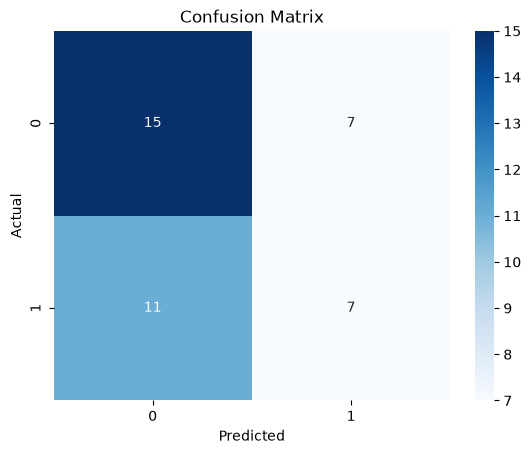

In [53]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True , fmt ='d',cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [65]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='blue',label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],linestyle='--',color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


NameError: name 'fpr' is not defined

<Figure size 800x600 with 0 Axes>